In [1]:
import numpy as np 
from tqdm import tqdm
from math import sqrt, pi,exp, cos
import matplotlib.pyplot as plt

# SZ-LAN: structured zeroth-order langevin

A brief tutorial on how to use SZ-LAN library

In [7]:
d = 2
l = 2
h = 1e-15
dtype = np.float64

a=20
b=0.2
c=2 * pi

def f(x):
    x1, x2 = x[0], x[1]
    
    numerator = 1 + np.cos(12 * np.sqrt(x1**2 + x2**2))
    denominator = 0.5 * (x1**2 + x2**2) + 2
    
    return - numerator / denominator


def approx_grad(x, h):
#    Q, _ = np.linalg.qr(np.random.randn(d, l))
    Q = np.eye(d)
    g = np.zeros(d, dtype=np.float64)
    fx = f(x)
    for i in range(l):
#        print("FN", f(x + h * Q[:, i])- fx)
        f_next = f(x + h * Q[:, i])
        g +=  ((( f_next - fx) / h) * Q[:, i].flatten())
    g *= d/l
    return g

g = approx_grad(np.array([0.0, 0.0], dtype=np.float64), h)
#print(f(np.zeros(2)))
#print(g)

In [62]:
d = 2
x = np.full((d, ), 3.0)
T = 60000
gamma = 0.1
h = 1e-10
iterator = tqdm(range(T))
values = [f(x).flatten().item()]
for k in iterator:
    gamma_k = gamma #/ sqrt(k + 1)
    beta_k =  1.0 / np.sqrt(k + 1)#(k + 1) / (k + 2)
    g_k = approx_grad(x, h)
    z_k = np.random.randn(d)
    x = x - gamma_k * g_k + beta_k *  z_k #* k /(k + 1)
    values.append(f(x).flatten().item())
    iterator.set_postfix({'f(x)' : values[-1], 'gamma' : gamma_k, 'beta' : beta_k, '|g|' : np.linalg.norm(g_k)})
    
print("min F ", np.min(values))

100%|██████████| 60000/60000 [00:59<00:00, 1000.55it/s, f(x)=-0.152, gamma=0.1, beta=0.00408, |g|=0.0549]  


min F  -0.2613667297011689


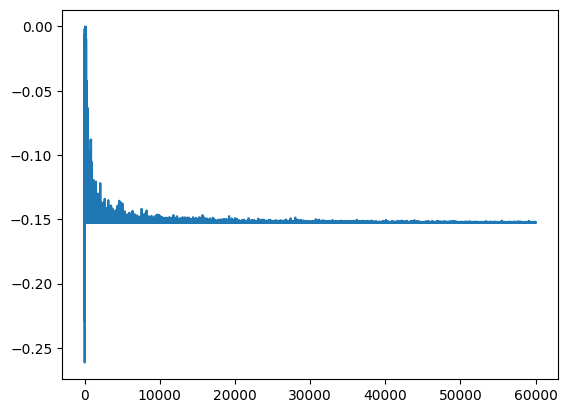

In [63]:
fig, ax = plt.subplots()
ax.plot(range(len(values)), values, '-')
#ax.set_yscale("log")
#ax.set_xscale("log")